# Libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import balanced_accuracy_score

# Load data

In [19]:
df = pd.read_csv('sample_data/imdb_sentiment.csv')
df['sentiment'] = df['sentiment'].map({'negative': 0, 'positive': 1})
df_lb = df[df['split'] == 'leaderboard'].copy()
df = df[df['split'] == 'labeled']
df.shape

(35000, 4)

In [ ]:
df.head()

,id,split,review,sentiment
0,1,labeled,I really liked this Summerslam due to the look...,1.0
1,2,labeled,Not many television shows appeal to quite as m...,1.0
2,3,labeled,The film quickly gets to a major chase scene w...,0.0
3,4,labeled,Jane Austen would definitely approve of this o...,1.0
4,5,labeled,Expectations were somewhat high for me when I ...,0.0


In [4]:
# Take a random subsample for training more efficiently
df_sub = df[df['split'] == 'labeled'].sample(10_000, replace=False, random_state=42)

# Clean data

In [ ]:
import string
import re


# Removing the html tags
def clean_html(text):
    # Identify HTML tags
    clean = re.compile('<.*?>')
    # Replace HTML tags with an empty string
    cleantext = re.sub(clean, '', text)
    return cleantext


def clean_text(text):
    text = text.lower()
    # Remove text within square brackets
    text = re.sub(r'\[.*?\]', '', text)
    # Remove punctuation using a predefined set of punctuation characters
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    # Remove words containing numbers
    text = re.sub(r'\w*\d\w*', '', text)
    # Remove quotation marks
    text = re.sub(r'["""]', '', text)
    # Remove newline characters
    text = re.sub(r'\n', '', text)

    return text

In [ ]:
# Clean reviews' text

df_sub['review'] = pd.DataFrame(df_sub['review'].apply(clean_html))
df_sub['review'] = pd.DataFrame(df_sub['review'].apply(clean_text))

# Classical ML

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
df_sub.head()

,id,split,review,sentiment
17813,17814,labeled,From the pen of Richard Condon (The Manchurian...,0.0
6857,6858,labeled,As far as I know I've seen most of Lucio Fulci...,1.0
7672,7673,labeled,I saw this film premiere Friday (1/19) night i...,1.0
9704,9705,labeled,I was really horrified by this eerie movie. Wh...,0.0
14303,14304,labeled,I am stunned to discover the amount of fans th...,0.0


In [ ]:
'''
stop_words: the words in the list will be removed from the resulting tokens.
lowercase: Convert all characters to lowercase before tokenizing.
ngram_range: The lower and upper boundary of the range of n-values for different n-grams to be extracted. Both limits included.
max features: build a vocabulary that only considers the top max_features
              ordered by term frequency across the corpus. If None, all features are used.
'''
vect = TfidfVectorizer(
    stop_words='english',
    lowercase=True,
    ngram_range=(1, 3),
    max_features=3_000
)

vect.fit(df_sub['review'])
# Create sparse matrix from the vectorizer
X = vect.transform(df_sub['review'])

In [ ]:
X.shape

(10000, 3000)

In [ ]:
df_X_tfidf = pd.DataFrame(X.toarray(), columns=vect.get_feature_names_out())
df_X_tfidf.head()

,000,10,10 10,10 br,10 br br,10 minutes,100,11,12,13,...,york,young,young girl,young man,young woman,younger,youth,zero,zombie,zombies
0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.06579,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.139247,0.0,0.0,0.124591,0.0,0.0,0.0,0.245856,0.0
2,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
4,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0


In [ ]:
# Set to 5 for better speed and less robustness

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
y = df_sub['sentiment']
X_train, X_test, y_train, y_test = train_test_split(df_X_tfidf, y, test_size=0.2, random_state=42)

## LR

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [ ]:
# Basic LR

lr = LogisticRegression(n_jobs=-1)
lr_cv = cross_validate(lr, X_train, y_train, scoring='accuracy')

In [ ]:
print('Validation accuracy:', lr_cv['test_score'].mean().round(2))

Validation accuracy: 0.86


## RF

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# These results correspond to only using 100 features

rf = RandomForestClassifier(n_jobs=-1, random_state=42)

params = [{
    'n_estimators': [100, 200, 300],
    'criterion': ['entropy', 'gini'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_depth': [3, 4, 5, 6, 8, 10, 20, 50],
    'max_features': [None, 'sqrt', 'log2', 0.5, 0.7, 0.9],
    'max_samples': [None, 0.5, 0.7, 0.9],
    'max_leaf_nodes': [None, 5, 10, 20],
    'min_weight_fraction_leaf': np.arange(0, 0.51, 0.1),
}]

rf_rs = RandomizedSearchCV(
    rf,
    n_iter=50,
    param_distributions=params,
    scoring='accuracy',
    cv=kf,
    refit='accuracy',
    return_train_score=True,
    n_jobs=-1
)

rf_rs.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions=[{'criterion': ['entropy', 'gini'],
                                         'max_depth': [3, 4, 5, 6, 8, 10, 20,
                                                       50],
                                         'max_features': [None, 'sqrt', 'log2',
                                                          0.5, 0.7, 0.9],
                                         'max_leaf_nodes': [None, 5, 10, 20],
                                         'max_samples': [None, 0.5, 0.7, 0.9],
                                         'min_samples_leaf': [1, 2, 4, 6],
                                         'min_samples_split': [2, 5, 10, 20],
                                         'min_weight_fraction_leaf': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]),
                                         'n_estimators': [100, 200, 300]}],
                   refit='accuracy', return_train_score=True,
                   scoring='accuracy')

In [ ]:
print('Mean Train Accuracy:', rf_rs.cv_results_['mean_train_score'][rf_rs.best_index_].round(2))
print('Mean Validation Accuracy:', rf_rs.cv_results_['mean_test_score'][rf_rs.best_index_].round(2))

Mean Train Accuracy: 0.72
Mean Validation Accuracy: 0.7


## GBDT

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# These results correspond to only using 100 features

gb = GradientBoostingClassifier(random_state=42)

params = [{
    'loss': ['exponential', 'log_loss'],
    'learning_rate': np.logspace(-3, 0, 10),
    'n_estimators': [20, 50, 100, 200, 300, 500, 1000],
    'subsample': [0.5, 0.7, 0.9, 1.0],
    'criterion': ['friedman_mse', 'squared_error'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6],
    'min_weight_fraction_leaf': [0.0, 0.1, 0.2, 0.3],
    'max_depth': [3, 4, 5, 6, 8, 10, 20],
    'min_impurity_decrease': [0.0, 0.01, 0.1],
    'max_features': [None, 'sqrt', 'log2', 0.5, 0.7],
    'max_leaf_nodes': [None, 5, 10, 20],
    'validation_fraction': [0.1, 0.2],
}]

gb_rs = RandomizedSearchCV(
    gb,
    n_iter=50,
    param_distributions=params,
    scoring='accuracy',
    cv=kf,
    refit='accuracy',
    return_train_score=True,
    n_jobs=-1
)

gb_rs.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions=[{'criterion': ['friedman_mse',
                                                       'squared_error'],
                                         'learning_rate': array([0.001     , 0.00215443, 0.00464159, 0.01      , 0.02154435,
       0.04641589, 0.1       , 0.21544347, 0.46415888, 1.        ]),
                                         'loss': ['exponential', 'log_los...
                                                          0.5, 0.7],
                                         'max_leaf_nodes': [None, 5, 10, 20],
                                         'min_impurity_decrease': [0.0, 0.01,
                                                                   0.1],
                                         'min_samples_leaf': [1, 2, 4, 6],
                                         'min_samples_split': [2, 5, 10, 20],
                                         'min_weight_fraction_leaf': [0.0, 0.1,
                                                                      0.2,
                                                                      0.3],
                                         'n_estimators': [20, 50, 100, 200, 300,
                                                          500, 1000],
                                         'subsample': [0.5, 0.7, 0.9, 1.0],
                                         'validation_fraction': [0.1, 0.2]}],
                   refit='accuracy', return_train_score=True,
                   scoring='accuracy')

In [ ]:
print('Mean Train Accuracy:', gb_rs.cv_results_['mean_train_score'][gb_rs.best_index_].round(2))
print('Mean Validation Accuracy:', gb_rs.cv_results_['mean_test_score'][gb_rs.best_index_].round(2))

Mean Train Accuracy: 0.81
Mean Validation Accuracy: 0.71


# Pre-trained Transformers

In [20]:
from transformers import pipeline

In [6]:
# Take "raw" (minimum cleaning) reviews, without feature engineering
X = df['review']
y = df['sentiment']
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42)

## DistilBERT

In [ ]:
model_dist = pipeline(
    'sentiment-analysis',
    model='distilbert/distilbert-base-uncased-finetuned-sst-2-english'
)

Device set to use cpu


In [ ]:
# Prediction
preds = model_dist(X_test_raw.values.tolist(), truncation=True)

In [ ]:
y_distil_pred_test = pd.DataFrame(preds)['label'].map({'NEGATIVE': 0, 'POSITIVE': 1})
bacc_distil_test = balanced_accuracy_score(y_test_raw, y_distil_pred_test)
print('Test Accuracy:', round(bacc_distil_test, 2))

Test Accuracy: 0.89


## RoBERTa (SST-2)


In [ ]:
model_rob_sst2 = pipeline(
    'sentiment-analysis',
    model='textattack/roberta-base-SST-2'
)

In [ ]:
# Prediction
preds = model_rob_sst2(X_test_raw.values.tolist(), truncation=True)

In [ ]:
# textattack/roberta-base-SST-2 outputs LABEL_0 (negative) / LABEL_1 (positive)
y_rob_sst2_pred_test = pd.DataFrame(preds)['label'].map({'LABEL_0': 0, 'LABEL_1': 1})
bacc_rob_sst2_test = balanced_accuracy_score(y_test_raw, y_rob_sst2_pred_test)
print('Test Accuracy:', round(bacc_rob_sst2_test, 2))

Test Accuracy: 0.92


## Sentiment Roberta

In [ ]:
model_rob = pipeline(
    'sentiment-analysis',
    model='siebert/sentiment-roberta-large-english'
)

Device set to use cpu


In [ ]:
# Prediction
preds = model_rob(X_test_raw.values.tolist(), truncation=True)

In [ ]:
y_roberta_pred_test = pd.DataFrame(preds)['label'].map({'NEGATIVE': 0, 'POSITIVE': 1})
bacc_roberta_test = balanced_accuracy_score(y_test_raw, y_roberta_pred_test)
print('Test Accuracy:', round(bacc_roberta_test, 2))

Test Accuracy: 0.95


# Fine-tuning a Pretrained Transformer

Roberta above was used purely off-the-shelf: it never saw a single one of our IMDB reviews during its own training. Fine-tuning it on some of our labeled data should let it adapt to this specific dataset's vocabulary/style and push accuracy higher.

**Note:** this needs a real GPU (or TPU) to run in reasonable time — don't attempt this on a laptop CPU. A free **Google Colab** or **Kaggle Notebooks** GPU runtime (e.g. a T4) is enough. With 20,000 training reviews and 5 epochs at fp16, expect roughly 50 minutes on a T4.

In [21]:
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

print('GPU available:', torch.cuda.is_available())

GPU available: True


In [31]:
# Use a modest slice of the training split so fine-tuning stays fast.
# 5,000 examples to adapt the model without a very long training run.
N_FINETUNE_TRAIN = 20_000

finetune_train_df = pd.DataFrame({
    'text': X_train_raw.values,
    'label': y_train_raw.values.astype(int),
}).sample(N_FINETUNE_TRAIN, random_state=42)

# Keep the same held-out test set used to evaluate every other model
finetune_test_df = pd.DataFrame({
    'text': X_test_raw.values,
    'label': y_test_raw.values.astype(int),
})

train_ds = Dataset.from_pandas(finetune_train_df, preserve_index=False)
test_ds = Dataset.from_pandas(finetune_test_df, preserve_index=False)

In [ ]:
MODEL_NAME = 'textattack/roberta-base-SST-2'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    # Capping max_length keeps tokenization/training fast without hurting
    # accuracy much, since most sentiment cues appear early in a review.
    return tokenizer(batch['text'], truncation=True, max_length=512)


train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

In [ ]:
model_finetuned = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    problem_type='single_label_classification',
)

training_args = TrainingArguments(
    output_dir='data/imdb/roberta_finetuned',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",  # Smooth decay down to 0 after warmup peak
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='balanced_accuracy',
    greater_is_better=True,
    logging_steps=50,
    fp16=torch.cuda.is_available(),  # fp16 needs a GPU; falls back safely on CPU
    report_to='none',
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {'balanced_accuracy': balanced_accuracy_score(labels, preds)}


trainer = Trainer(
    model=model_finetuned,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

In [34]:
print('Baseline:', trainer.evaluate())

Training Loss,Validation Loss,Epoch,Balanced Accuracy
No log,0.212335,0,0.923836


Baseline: {'eval_loss': 0.2123350352048874, 'eval_balanced_accuracy': 0.9238364562430507}


In [35]:
# On a Colab/Kaggle T4 GPU this takes roughly 50 minutes for 20,000 examples, 5 epochs and token max length of 512.
# On CPU this would take hours — do not run this cell without a GPU/TPU runtime.
trainer.train()

Epoch,Training Loss,Validation Loss,Balanced Accuracy
1,0.193793,0.171558,0.945504
2,0.161027,0.224246,0.941380
3,0.098630,0.224046,0.952472
4,0.050130,0.247991,0.954667
5,0.030423,0.274589,0.952869


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6250, training_loss=0.10388246484756469, metrics={'train_runtime': 3089.2577, 'train_samples_per_second': 32.37, 'train_steps_per_second': 2.023, 'total_flos': 2.594658161323968e+16, 'train_loss': 0.10388246484756469, 'epoch': 5.0})

In [41]:
bacc_rob_sst2_ft_test = trainer.evaluate()['eval_balanced_accuracy']
print('After fine-tunning:', bacc_rob_sst2_ft_test)

Training Loss,Validation Loss,Epoch,Balanced Accuracy
0.030423,0.247991,5,0.954667


After fine-tunning: 0.9546665670835132


# Test

Note that DistilBERT and the off-the-shelf Roberta were not even trained on our data!

As shown above, fine-tuning Roberta on a slice of our own training data does push its accuracy past the pretrained version.

In [ ]:
y_lr_pred_test = lr.predict(X_test)
y_rf_pred_test = rf_rs.predict(X_test)
y_gb_pred_test = gb_rs.predict(X_test)

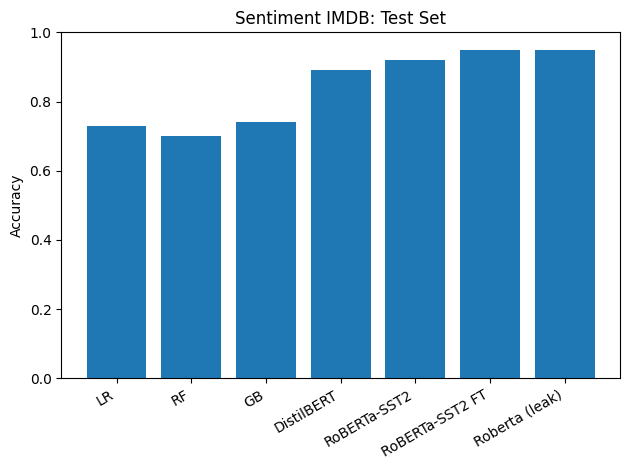

In [49]:
model_accuracies = {
    'LR': bacc_lr_test,
    'RF': bacc_rf_test,
    'GB': bacc_gb_test,
    'DistilBERT': bacc_distil_test,
    'RoBERTa-SST2': bacc_rob_sst2_test,
    'RoBERTa-SST2 FT': bacc_rob_sst2_ft_test,
    'Roberta (leak)': bacc_roberta_test,
}
x = range(len(model_accuracies))

plt.bar(x, model_accuracies.values())
plt.xticks(x, model_accuracies.keys(), rotation=30, ha='right')
plt.ylim((0, 1))
plt.ylabel('Accuracy')
plt.title('Sentiment IMDB: Test Set')
plt.tight_layout()
plt.show()

# Leaderboard

In [ ]:
lb_df = pd.DataFrame({
    'id': df_lb['id'].values,
    'text': df_lb['review'].values,
})

lb_ds = Dataset.from_pandas(lb_df, preserve_index=False)
lb_ds = lb_ds.map(tokenize, batched=True)

In [ ]:
# Prediction

# no ground-truth labels here — compute_metrics would crash trying to score against them
trainer.compute_metrics = None
preds_lb = trainer.predict(lb_ds)
trainer.compute_metrics = compute_metrics  # restore in case you need it again later

In [ ]:
y_lb_pred = preds_lb.predictions.argmax(axis=-1)

In [ ]:
submission_df = pd.DataFrame({
    'id': lb_df['id'],
    'prediction': y_lb_pred,
})

In [ ]:
submission_df.to_csv('../../data/imdb/submission_roberta.csv')